## Q2.Unsupervised Learning

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

df = pd.read_csv('q2_customers.csv')

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

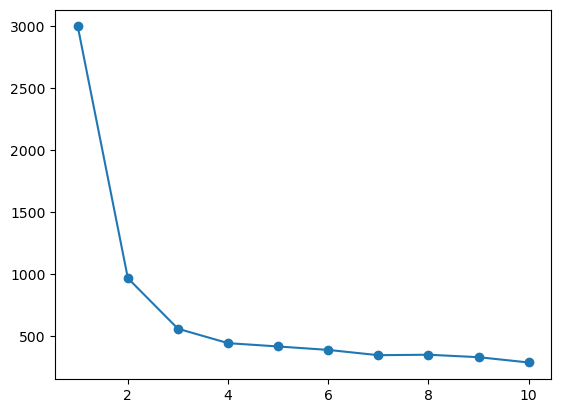

In [2]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.show()

## KMeans

In [3]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_data)

centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

## PCA

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(scaled_data)

df['PC1'] = components[:,0]
df['PC2'] = components[:,1]

print(pca.explained_variance_ratio_)

[0.83560354 0.05568764]


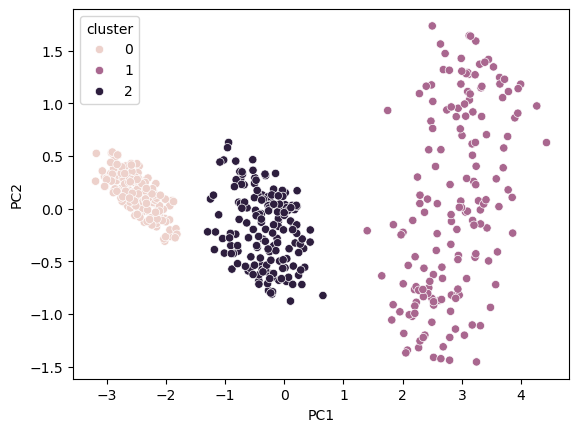

In [5]:
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df)
plt.show()